#**Model**


[14:02:40] LOADING DATA
Train shape   : (4000, 21)
Feature shape : (4000, 20)
Classes       : ['0', '1']
Device        : cuda
Test shape    : (1000, 21)
Test labels   : present

[14:02:40] STARTING NESTED CV (5 OUTER x 2 INNER)

[14:02:40] OUTER FOLD 1/5
  trial 1/3 | acc=0.95875 | f1=0.91842 | rec=0.93813 | prec=0.89952 | mcc=0.89118 | auc=0.99210 | logloss=0.48983 | thr=0.397 | pos_w=1.250
  trial 2/3 | acc=0.93906 | f1=0.87619 | rec=0.87121 | prec=0.88123 | mcc=0.83580 | auc=0.97110 | logloss=0.52147 | thr=0.430 | pos_w=1.250
  trial 3/3 | acc=0.96219 | f1=0.92590 | rec=0.95455 | prec=0.89893 | mcc=0.90128 | auc=0.99081 | logloss=0.17798 | thr=0.440 | pos_w=1.250
  best hp  : embed=192 | heads=4 | depth=3 | ff_mult=2.0 | drop=0.1 | tok_drop=0.02 | lr=0.0008 | wd=1e-05 | bs=1024
  best thr : 0.440
  fold result | acc=0.97250 | prec=0.91509 | rec=0.97980 | spec=0.97010 | f1=0.94634 | mcc=0.92886 | auc=0.99838 | logloss=0.05980

[14:03:08] OUTER FOLD 2/5
  trial 1/3 | acc=0.95406 | f1

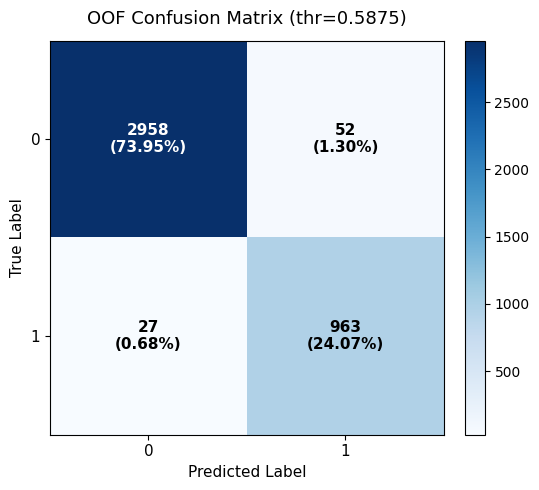


--------------------------------------------------------------------------------
OOF CALIBRATION INPUT PREVIEW (use for calibration / Platt / Isotonic)
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.001786
      0       0.002609
      0       0.001810
      1       0.914371
      0       0.001764
      1       0.978817
      0       0.001227
      0       0.002431
      0       0.003602
      0       0.004751

Shape: (4000, 2)


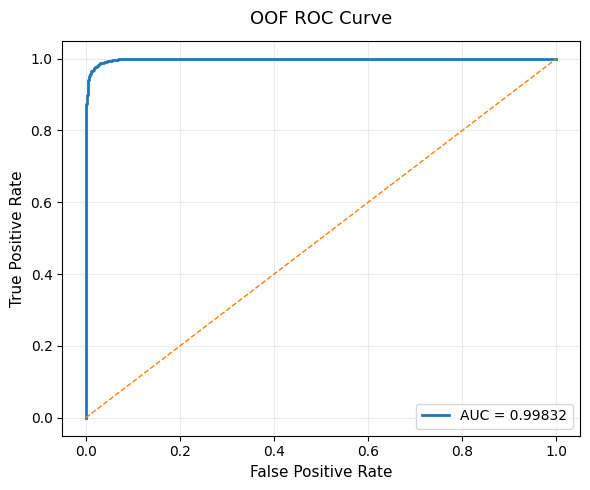


--------------------------------------------------------------------------------
OOF ROC ARRAYS PREVIEW
--------------------------------------------------------------------------------
     fpr      tpr  threshold
0.000000 0.000000        inf
0.000000 0.001010   0.987089
0.000000 0.124242   0.980009
0.000000 0.126263   0.979995
0.000000 0.782828   0.953364
0.000332 0.782828   0.953286
0.000332 0.803030   0.948072
0.000664 0.803030   0.948066
0.000664 0.815152   0.944652
0.000664 0.817172   0.944466

Shape: (120, 3)

--------------------------------------------------------------------------------
FINAL VALIDATION CALIBRATION INPUT PREVIEW (good for Platt / Isotonic)
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.001127
      0       0.003325
      0       0.001128
      1       0.996026
      0       0.004302
      1       0.996635
      1       0.994640
      0       0.001211
      0       0.001134
      0       

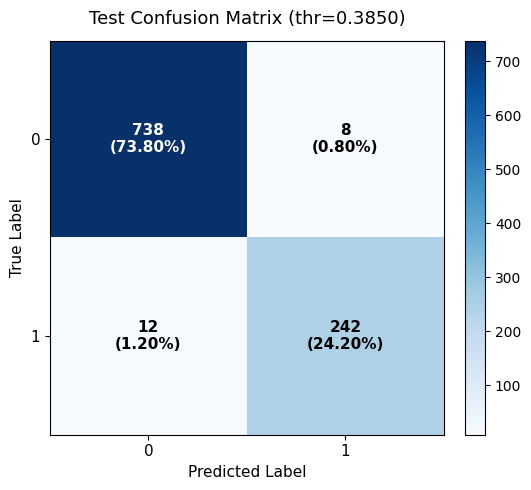


--------------------------------------------------------------------------------
TEST CALIBRATION INPUT PREVIEW
--------------------------------------------------------------------------------
 y_true  y_prob_class1
      0       0.001152
      0       0.002671
      1       0.996089
      0       0.028000
      0       0.001228
      0       0.001195
      1       0.996077
      0       0.001250
      0       0.001135
      0       0.002624

Shape: (1000, 2)


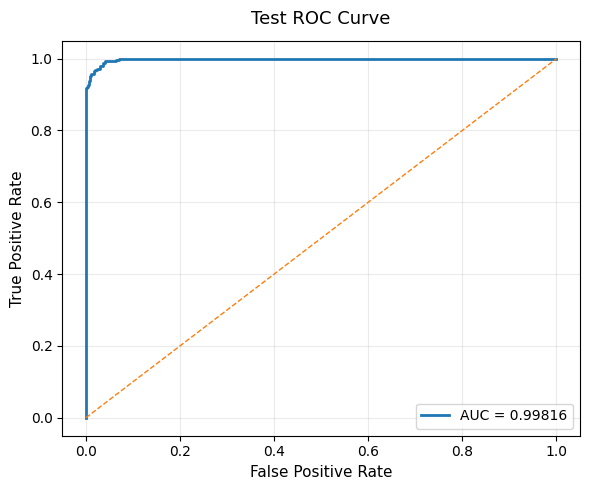


--------------------------------------------------------------------------------
TEST ROC ARRAYS PREVIEW
--------------------------------------------------------------------------------
     fpr      tpr  threshold
0.000000 0.000000        inf
0.000000 0.003937   0.996809
0.000000 0.909449   0.850380
0.001340 0.909449   0.844788
0.001340 0.917323   0.806052
0.002681 0.917323   0.801519
0.002681 0.921260   0.744151
0.005362 0.921260   0.715584
0.005362 0.925197   0.711112
0.006702 0.925197   0.693031

Shape: (38, 3)


In [ ]:
import os
import json
import time
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    matthews_corrcoef,
    confusion_matrix,
    balanced_accuracy_score,
    brier_score_loss,
    roc_curve,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")


# ============================================================
# GLOBAL VARIABLES
# ============================================================

# ---------- DATA ----------
TRAIN_PATH = "/content/train_selected.csv"
TEST_PATH  = "/content/test_selected.csv"
TARGET_COLUMN = "lung_cancer_risk"
ID_COLUMNS = []
DROP_COLUMNS = []

# ---------- OUTPUT ----------
OUTPUT_DIR = "/content/fast_nested_tabfgt_fast_f1fix"
SAVE_OUTPUTS = False
SHOW_PLOTS = False

# ---------- REPRO ----------
SEED = 42

# ---------- CV ----------
OUTER_FOLDS = 5
INNER_FOLDS = 2

# ---------- SPEED / TRAINING ----------
N_TRIALS = 3
MAX_EPOCHS_INNER = 6
MAX_EPOCHS_OUTER = 10
MAX_EPOCHS_FINAL = 12

PATIENCE_INNER = 2
PATIENCE_OUTER = 3
PATIENCE_FINAL = 3

OUTER_DEV_VALID_SIZE = 0.12
FINAL_VALID_SIZE = 0.10

USE_AMP = True
NUM_WORKERS = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- THRESHOLD ----------
THRESHOLD_GRID = np.linspace(0.16, 0.60, 177)
ACC_DROP_TOL = 0.0015

# Dynamic precision protection
MIN_DYNAMIC_PRECISION = 0.970
PRECISION_RELAX = 0.012

# ---------- LOSS ----------
USE_MILD_POS_WEIGHT = True
POS_WEIGHT_POWER = 0.35
POS_WEIGHT_MAX = 1.25

# ---------- HP SELECTION ----------
HP_ACC_TOL = 0.0015

# ---------- FINAL ENSEMBLE ----------
FINAL_ENSEMBLE_SEEDS = [42]

# ---------- MODEL CANDIDATES ----------
SEARCH_CANDIDATES = [
    {"embed_dim": 128, "num_heads": 4, "depth": 2, "ff_mult": 2.0, "dropout": 0.08, "token_dropout": 0.01, "lr": 1.0e-3, "weight_decay": 1e-5, "batch_size": 2048},
    {"embed_dim": 160, "num_heads": 4, "depth": 2, "ff_mult": 2.0, "dropout": 0.10, "token_dropout": 0.02, "lr": 8.0e-4, "weight_decay": 1e-5, "batch_size": 2048},
    {"embed_dim": 192, "num_heads": 4, "depth": 3, "ff_mult": 2.0, "dropout": 0.10, "token_dropout": 0.02, "lr": 8.0e-4, "weight_decay": 1e-5, "batch_size": 1024},
]


# ============================================================
# HELPERS
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass


def now():
    return time.strftime("%H:%M:%S")


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def safe_read_csv(path):
    if path is None or str(path).strip() == "":
        return None
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path)


def to_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


def clip_probs(prob, eps=1e-7):
    return np.clip(np.asarray(prob, dtype=np.float64), eps, 1 - eps)


def safe_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, prob))


def safe_pr_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, prob))


def metric_score_binary(y_true, y_pred, metric_name="accuracy"):
    if metric_name == "accuracy":
        return accuracy_score(y_true, y_pred)
    if metric_name == "f1":
        return f1_score(y_true, y_pred, zero_division=0)
    if metric_name == "mcc":
        return matthews_corrcoef(y_true, y_pred)
    if metric_name == "balanced_accuracy":
        return balanced_accuracy_score(y_true, y_pred)
    raise ValueError(f"Unsupported metric: {metric_name}")


def _threshold_table(y_true, prob, grid):
    rows = []
    prob = clip_probs(prob)

    for t in grid:
        pred = (prob >= t).astype(int)
        acc = accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)
        f1v = f1_score(y_true, pred, zero_division=0)
        mcc = matthews_corrcoef(y_true, pred)

        rows.append({
            "threshold": float(t),
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1v),
            "mcc": float(mcc),
        })

    return pd.DataFrame(rows)


def _pick_best_threshold_from_df(df_thr: pd.DataFrame) -> float:
    """
    Tie-break order after accuracy safety:
    1) max F1
    2) max Recall
    3) max Accuracy
    4) max MCC
    5) max Precision
    6) lower threshold
    """
    if df_thr.empty:
        return 0.50

    df_thr = df_thr.sort_values(
        by=["f1", "recall", "accuracy", "mcc", "precision", "threshold"],
        ascending=[False, False, False, False, False, True]
    ).reset_index(drop=True)

    return float(df_thr.loc[0, "threshold"])


def tune_threshold_constrained(
    y_true,
    prob,
    grid=None,
    acc_drop_tol=0.0015,
    min_dynamic_precision=0.970,
    precision_relax=0.012,
):
    """
    Accuracy-safe threshold tuning with dynamic precision protection.

    Steps:
    1) compute full threshold table
    2) keep thresholds within best-accuracy tolerance
    3) estimate precision at the best-accuracy operating region
    4) allow a small precision relaxation from that reference
    5) inside that safe region, maximize F1 -> Recall -> Accuracy -> MCC
    """
    if grid is None:
        grid = np.linspace(0.16, 0.60, 177)

    prob = clip_probs(prob)
    thr_df = _threshold_table(y_true, prob, grid)

    best_acc = float(thr_df["accuracy"].max())
    acc_floor = best_acc - float(acc_drop_tol)

    safe_df = thr_df.loc[thr_df["accuracy"] >= acc_floor].copy()
    if safe_df.empty:
        safe_df = thr_df.copy()

    best_acc_df = thr_df.loc[thr_df["accuracy"] >= best_acc - 1e-12].copy()
    best_acc_df = best_acc_df.sort_values(
        by=["f1", "recall", "mcc", "precision", "threshold"],
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)

    ref_precision = float(best_acc_df.loc[0, "precision"])
    precision_floor = max(float(min_dynamic_precision), ref_precision - float(precision_relax))

    guarded_df = safe_df.loc[safe_df["precision"] >= precision_floor].copy()
    if guarded_df.empty:
        guarded_df = safe_df.copy()

    return _pick_best_threshold_from_df(guarded_df)


def choose_best_hp_info(info_list, acc_tol=0.0015):
    """
    Keep only HPs within best accuracy tolerance,
    then choose the one with better F1 / recall / MCC.
    """
    rows = []
    for i, info in enumerate(info_list):
        m = info["metrics"]
        rows.append({
            "idx": i,
            "accuracy": float(m["accuracy"]),
            "f1": float(m["f1"]),
            "recall": float(m["recall"]),
            "precision": float(m["precision"]),
            "mcc": float(m["mcc"]),
            "logloss": float(m["logloss"]),
        })

    df = pd.DataFrame(rows)
    best_acc = float(df["accuracy"].max())

    keep = df.loc[df["accuracy"] >= best_acc - float(acc_tol)].copy()
    keep = keep.sort_values(
        by=["f1", "recall", "mcc", "precision", "accuracy", "logloss"],
        ascending=[False, False, False, False, False, True]
    ).reset_index(drop=True)

    return info_list[int(keep.loc[0, "idx"])]


def compute_metrics(y_true, prob, threshold=0.5):
    prob = clip_probs(prob)
    pred = (prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "specificity": float(specificity),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "roc_auc": safe_auc(y_true, prob),
        "pr_auc": safe_pr_auc(y_true, prob),
        "logloss": float(log_loss(y_true, prob, labels=[0, 1])),
        "brier": float(brier_score_loss(y_true, prob)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def plot_conf_matrix(cm, title="Confusion Matrix", class_names=("0", "1")):
    cm = np.asarray(cm)
    total = cm.sum()
    pct = (cm / total * 100.0) if total > 0 else np.zeros_like(cm, dtype=float)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_yticklabels(class_names, fontsize=11)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)

    thresh = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                f"{cm[i, j]}\n({pct[i, j]:.2f}%)",
                ha="center", va="center",
                fontsize=11,
                fontweight="bold",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()


def plot_roc_curve_from_prob(y_true, prob, title="ROC Curve"):
    if len(np.unique(y_true)) < 2:
        print(f"{title}: skipped because only one class is present.")
        return None, None, None, np.nan

    fpr, tpr, thresholds = roc_curve(y_true, prob)
    auc_val = roc_auc_score(y_true, prob)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.5f}")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    ax.legend(loc="lower right")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    return fpr, tpr, thresholds, auc_val


def print_preview_table(df, title, n=10):
    print("\n" + "-" * 80)
    print(title)
    print("-" * 80)
    print(df.head(n).to_string(index=False))
    print(f"\nShape: {df.shape}")


def hp_to_str(hp):
    return (
        f"embed={hp['embed_dim']} | heads={hp['num_heads']} | depth={hp['depth']} | "
        f"ff_mult={hp['ff_mult']} | drop={hp['dropout']} | tok_drop={hp['token_dropout']} | "
        f"lr={hp['lr']} | wd={hp['weight_decay']} | bs={hp['batch_size']}"
    )


# ============================================================
# PREPROCESSOR
# ============================================================

class FoldPreprocessor:
    def __init__(self):
        self.imputer = SimpleImputer(strategy="median")
        self.scaler = StandardScaler()

    def fit(self, X_df):
        X_num = to_numeric_df(X_df)
        X_imp = self.imputer.fit_transform(X_num)
        self.scaler.fit(X_imp)
        return self

    def transform(self, X_df):
        X_num = to_numeric_df(X_df)
        X_imp = self.imputer.transform(X_num)
        X_scaled = self.scaler.transform(X_imp)
        X_scaled = np.clip(X_scaled, -8.0, 8.0).astype(np.float32)
        return X_scaled

    def fit_transform(self, X_df):
        self.fit(X_df)
        return self.transform(X_df)


# ============================================================
# MODEL
# ============================================================

class NumericFeatureTokenizer(nn.Module):
    """
    Each scalar feature becomes a learnable token.
    token_j = x_j * W_j + B_j + E_j
    """
    def __init__(self, n_features, embed_dim, token_dropout=0.01):
        super().__init__()
        self.n_features = n_features
        self.embed_dim = embed_dim
        self.token_dropout = float(token_dropout)

        self.weight = nn.Parameter(torch.randn(n_features, embed_dim) * 0.02)
        self.bias = nn.Parameter(torch.zeros(n_features, embed_dim))
        self.feature_embed = nn.Parameter(torch.randn(n_features, embed_dim) * 0.02)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        tokens = x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0) + self.feature_embed.unsqueeze(0)

        if self.training and self.token_dropout > 0:
            keep = (torch.rand((x.size(0), x.size(1), 1), device=x.device) > self.token_dropout).float()
            tokens = tokens * keep

        tokens = self.norm(tokens)
        return tokens


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_mult=2.0, dropout=0.10):
        super().__init__()
        ff_dim = int(embed_dim * ff_mult)

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.drop1 = nn.Dropout(dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff1 = nn.Linear(embed_dim, ff_dim * 2)
        self.ff2 = nn.Linear(ff_dim, embed_dim)
        self.drop2 = nn.Dropout(dropout)

        self.gate = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        y = self.norm1(x)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x = x + self.drop1(attn_out)

        y = self.norm2(x)
        a, b = self.ff1(y).chunk(2, dim=-1)
        y = a * F.gelu(b)
        y = self.ff2(self.drop2(y))

        gate = self.gate(x)
        x = x + gate * y
        return x


class TabFGT(nn.Module):
    """
    Faster custom transformer for encoded numeric tabular data.
    Lighter head: CLS + mean pooling only.
    """
    def __init__(
        self,
        input_dim,
        embed_dim=160,
        num_heads=4,
        depth=2,
        ff_mult=2.0,
        dropout=0.10,
        token_dropout=0.01,
    ):
        super().__init__()

        self.tokenizer = NumericFeatureTokenizer(
            n_features=input_dim,
            embed_dim=embed_dim,
            token_dropout=token_dropout
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.cls_bias = nn.Parameter(torch.zeros(1, 1, embed_dim))

        self.blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ff_mult=ff_mult,
                dropout=dropout
            )
            for _ in range(depth)
        ])

        self.final_norm = nn.LayerNorm(embed_dim)

        head_dim = embed_dim * 2
        hidden2 = max(embed_dim, 128)

        self.head = nn.Sequential(
            nn.LayerNorm(head_dim),
            nn.Linear(head_dim, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, hidden2 // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2 // 2, 1),
        )

    def forward(self, x):
        tok = self.tokenizer(x)
        cls = self.cls_token.expand(x.size(0), -1, -1) + self.cls_bias
        tok = torch.cat([cls, tok], dim=1)

        for block in self.blocks:
            tok = block(tok)

        tok = self.final_norm(tok)

        cls_tok = tok[:, 0]
        feat_tok = tok[:, 1:]
        mean_tok = feat_tok.mean(dim=1)

        rep = torch.cat([cls_tok, mean_tok], dim=1)
        out = self.head(rep).squeeze(1)
        return out


# ============================================================
# DATALOADER
# ============================================================

def make_loader(X, y=None, batch_size=1024, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    if y is None:
        ds = TensorDataset(X_t)
    else:
        y_t = torch.tensor(y, dtype=torch.float32)
        ds = TensorDataset(X_t, y_t)

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )


@torch.no_grad()
def predict_proba(model, X, batch_size=1024):
    model.eval()
    loader = make_loader(X, y=None, batch_size=batch_size, shuffle=False)
    probs = []

    for batch in loader:
        xb = batch[0].to(DEVICE, non_blocking=True)
        logits = model(xb)
        p = torch.sigmoid(logits).detach().cpu().numpy()
        probs.append(p)

    return np.concatenate(probs).astype(np.float64)


@torch.no_grad()
def predict_logits(model, X, batch_size=1024):
    model.eval()
    loader = make_loader(X, y=None, batch_size=batch_size, shuffle=False)
    logits_all = []

    for batch in loader:
        xb = batch[0].to(DEVICE, non_blocking=True)
        logits = model(xb).detach().cpu().numpy()
        logits_all.append(logits)

    return np.concatenate(logits_all).astype(np.float64)


def train_one_model(
    X_train, y_train,
    X_valid, y_valid,
    hp,
    max_epochs=12,
    patience=3,
    seed=42
):
    set_seed(seed)

    model = TabFGT(
        input_dim=X_train.shape[1],
        embed_dim=hp["embed_dim"],
        num_heads=hp["num_heads"],
        depth=hp["depth"],
        ff_mult=hp["ff_mult"],
        dropout=hp["dropout"],
        token_dropout=hp["token_dropout"],
    ).to(DEVICE)

    train_loader = make_loader(X_train, y_train, batch_size=hp["batch_size"], shuffle=True)
    valid_loader = make_loader(X_valid, y_valid, batch_size=max(1024, hp["batch_size"]), shuffle=False)

    pos_count = max(float(np.sum(np.asarray(y_train) == 1)), 1.0)
    neg_count = max(float(np.sum(np.asarray(y_train) == 0)), 1.0)

    if USE_MILD_POS_WEIGHT:
        pos_weight_value = float(np.clip((neg_count / pos_count) ** POS_WEIGHT_POWER, 1.0, POS_WEIGHT_MAX))
    else:
        pos_weight_value = 1.0

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"]
    )

    steps_per_epoch = max(1, len(train_loader))
    total_steps = max(1, max_epochs * steps_per_epoch)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=hp["lr"],
        total_steps=total_steps,
        pct_start=0.20,
        div_factor=8.0,
        final_div_factor=80.0,
    )

    use_amp_now = bool(USE_AMP and DEVICE.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp_now)

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = np.inf
    best_epoch = 0
    bad_epochs = 0
    min_delta = 5e-4

    for epoch in range(1, max_epochs + 1):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp_now):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

        model.eval()
        val_probs = []
        for xb, _ in valid_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp_now):
                logits = model(xb)
                p = torch.sigmoid(logits)
            val_probs.append(p.detach().cpu().numpy())

        val_probs = np.concatenate(val_probs).astype(np.float64)
        val_loss = log_loss(y_valid, clip_probs(val_probs), labels=[0, 1])

        if val_loss < best_val_loss - min_delta:
            best_val_loss = float(val_loss)
            best_epoch = int(epoch)
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    model.load_state_dict(best_state)
    return model, best_epoch, best_val_loss, pos_weight_value


# ============================================================
# INNER CV
# ============================================================

def inner_cv_score(X_df, y, hp, seed=42):
    skf = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=seed)
    oof_prob = np.zeros(len(y), dtype=np.float64)
    pos_weights_used = []

    for inner_fold, (tr_idx, va_idx) in enumerate(skf.split(X_df, y), start=1):
        X_tr_df = X_df.iloc[tr_idx].reset_index(drop=True)
        X_va_df = X_df.iloc[va_idx].reset_index(drop=True)
        y_tr = y[tr_idx]
        y_va = y[va_idx]

        prep = FoldPreprocessor()
        X_tr = prep.fit_transform(X_tr_df)
        X_va = prep.transform(X_va_df)

        model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
            X_tr, y_tr,
            X_va, y_va,
            hp=hp,
            max_epochs=MAX_EPOCHS_INNER,
            patience=PATIENCE_INNER,
            seed=seed + inner_fold * 77
        )
        pos_weights_used.append(float(pos_weight_value))

        prob = predict_proba(model, X_va, batch_size=max(1024, hp["batch_size"]))
        oof_prob[va_idx] = prob

    best_thr = tune_threshold_constrained(
        y_true=y,
        prob=oof_prob,
        grid=THRESHOLD_GRID,
        acc_drop_tol=ACC_DROP_TOL,
        min_dynamic_precision=MIN_DYNAMIC_PRECISION,
        precision_relax=PRECISION_RELAX,
    )
    metrics = compute_metrics(y, oof_prob, threshold=best_thr)

    return {
        "hp": hp,
        "threshold": best_thr,
        "metrics": metrics,
        "score": metrics["accuracy"],
        "mean_pos_weight": float(np.mean(pos_weights_used)) if len(pos_weights_used) > 0 else 1.0,
    }


# ============================================================
# LOAD DATA
# ============================================================

set_seed(SEED)
ensure_dir(OUTPUT_DIR)

print("\n" + "=" * 80)
print(f"[{now()}] LOADING DATA")
print("=" * 80)

train_df = safe_read_csv(TRAIN_PATH)
test_df = safe_read_csv(TEST_PATH)

if TARGET_COLUMN not in train_df.columns:
    raise ValueError(f"Target column '{TARGET_COLUMN}' not found.")

drop_train = list(set(ID_COLUMNS + DROP_COLUMNS + [TARGET_COLUMN]))
X_train_df = train_df.drop(columns=[c for c in drop_train if c in train_df.columns], errors="ignore").copy()
y_raw = train_df[TARGET_COLUMN].copy()

le = LabelEncoder()
y = le.fit_transform(y_raw)

if len(le.classes_) != 2:
    raise ValueError(f"Binary classification only. Found classes: {list(le.classes_)}")

class_names = [str(x) for x in le.classes_]

print(f"Train shape   : {train_df.shape}")
print(f"Feature shape : {X_train_df.shape}")
print(f"Classes       : {class_names}")
print(f"Device        : {DEVICE}")

if test_df is not None:
    drop_test = list(set(ID_COLUMNS + DROP_COLUMNS + [TARGET_COLUMN]))
    X_test_df = test_df.drop(columns=[c for c in drop_test if c in test_df.columns], errors="ignore").copy()

    if TARGET_COLUMN in test_df.columns:
        y_test = le.transform(test_df[TARGET_COLUMN])
        has_test_labels = True
    else:
        y_test = None
        has_test_labels = False

    print(f"Test shape    : {test_df.shape}")
    print(f"Test labels   : {'present' if has_test_labels else 'absent'}")
else:
    X_test_df = None
    y_test = None
    has_test_labels = False


# ============================================================
# NESTED CV
# ============================================================

print("\n" + "=" * 80)
print(f"[{now()}] STARTING NESTED CV ({OUTER_FOLDS} OUTER x {INNER_FOLDS} INNER)")
print("=" * 80)

outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED)

oof_prob = np.zeros(len(y), dtype=np.float64)
outer_rows = []
outer_thresholds = []
outer_best_hps = []
outer_test_probs = []

candidate_pool = SEARCH_CANDIDATES[:N_TRIALS]

for outer_fold, (dev_idx, hold_idx) in enumerate(outer_cv.split(X_train_df, y), start=1):
    print(f"\n[{now()}] OUTER FOLD {outer_fold}/{OUTER_FOLDS}")

    X_dev_df = X_train_df.iloc[dev_idx].reset_index(drop=True)
    y_dev = y[dev_idx]

    X_hold_df = X_train_df.iloc[hold_idx].reset_index(drop=True)
    y_hold = y[hold_idx]

    fold_infos = []

    for trial_id, hp in enumerate(candidate_pool, start=1):
        info = inner_cv_score(
            X_df=X_dev_df,
            y=y_dev,
            hp=hp,
            seed=SEED + outer_fold * 100 + trial_id
        )
        fold_infos.append(info)

        m = info["metrics"]
        print(
            f"  trial {trial_id}/{len(candidate_pool)} | "
            f"acc={m['accuracy']:.5f} | f1={m['f1']:.5f} | rec={m['recall']:.5f} | "
            f"prec={m['precision']:.5f} | mcc={m['mcc']:.5f} | "
            f"auc={m['roc_auc']:.5f} | logloss={m['logloss']:.5f} | "
            f"thr={info['threshold']:.3f} | pos_w={info['mean_pos_weight']:.3f}"
        )

    best_info = choose_best_hp_info(fold_infos, acc_tol=HP_ACC_TOL)
    best_hp = best_info["hp"]
    best_thr = best_info["threshold"]

    outer_best_hps.append(best_hp)
    outer_thresholds.append(best_thr)

    print(f"  best hp  : {hp_to_str(best_hp)}")
    print(f"  best thr : {best_thr:.3f}")

    X_tr_df, X_va_df, y_tr, y_va = train_test_split(
        X_dev_df, y_dev,
        test_size=OUTER_DEV_VALID_SIZE,
        random_state=SEED + outer_fold,
        stratify=y_dev
    )

    prep = FoldPreprocessor()
    X_tr = prep.fit_transform(X_tr_df)
    X_va = prep.transform(X_va_df)
    X_hold = prep.transform(X_hold_df)

    model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
        X_tr, y_tr,
        X_va, y_va,
        hp=best_hp,
        max_epochs=MAX_EPOCHS_OUTER,
        patience=PATIENCE_OUTER,
        seed=SEED + outer_fold * 1000
    )

    hold_prob = predict_proba(model, X_hold, batch_size=max(1024, best_hp["batch_size"]))
    oof_prob[hold_idx] = hold_prob

    fold_metrics = compute_metrics(y_hold, hold_prob, threshold=best_thr)
    fold_metrics["outer_fold"] = outer_fold
    fold_metrics["best_epoch"] = best_epoch
    fold_metrics["best_val_loss"] = best_val_loss
    fold_metrics["pos_weight"] = float(pos_weight_value)
    outer_rows.append(fold_metrics)

    print(
        f"  fold result | acc={fold_metrics['accuracy']:.5f} | "
        f"prec={fold_metrics['precision']:.5f} | rec={fold_metrics['recall']:.5f} | "
        f"spec={fold_metrics['specificity']:.5f} | f1={fold_metrics['f1']:.5f} | "
        f"mcc={fold_metrics['mcc']:.5f} | auc={fold_metrics['roc_auc']:.5f} | "
        f"logloss={fold_metrics['logloss']:.5f}"
    )

    if X_test_df is not None:
        X_test_proc = prep.transform(X_test_df)
        test_prob_fold = predict_proba(model, X_test_proc, batch_size=max(1024, best_hp["batch_size"]))
        outer_test_probs.append(test_prob_fold)


# ============================================================
# OOF SUMMARY
# ============================================================

outer_df = pd.DataFrame(outer_rows)

global_threshold = tune_threshold_constrained(
    y_true=y,
    prob=oof_prob,
    grid=THRESHOLD_GRID,
    acc_drop_tol=ACC_DROP_TOL,
    min_dynamic_precision=MIN_DYNAMIC_PRECISION,
    precision_relax=PRECISION_RELAX,
)

oof_metrics = compute_metrics(y, oof_prob, threshold=global_threshold)

print("\n" + "=" * 80)
print(f"[{now()}] NESTED CV SUMMARY")
print("=" * 80)
print(outer_df[
    ["outer_fold", "accuracy", "precision", "recall", "specificity", "f1",
     "mcc", "balanced_accuracy", "roc_auc", "pr_auc", "logloss", "threshold", "pos_weight"]
].round(5).to_string(index=False))

print("\nOOF SUMMARY")
print(pd.DataFrame([oof_metrics]).round(5).to_string(index=False))

if SHOW_PLOTS:
    cm_oof = confusion_matrix(y, (oof_prob >= global_threshold).astype(int), labels=[0, 1])
    plot_conf_matrix(
        cm_oof,
        title=f"OOF Confusion Matrix (thr={global_threshold:.3f})",
        class_names=class_names
    )


# ============================================================
# FINAL HP CHOICE
# ============================================================

hp_keys = [tuple(sorted(hp.items())) for hp in outer_best_hps]
hp_counter = Counter(hp_keys)
max_count = max(hp_counter.values())
candidates = [dict(k) for k, v in hp_counter.items() if v == max_count]

if len(candidates) == 1:
    final_best_hp = candidates[0]
else:
    rows = []
    for cand in candidates:
        mask = [hp == cand for hp in outer_best_hps]
        rows.append({
            "hp": cand,
            "mean_acc": float(outer_df.loc[mask, "accuracy"].mean()),
            "mean_f1": float(outer_df.loc[mask, "f1"].mean()),
            "mean_recall": float(outer_df.loc[mask, "recall"].mean()),
            "mean_mcc": float(outer_df.loc[mask, "mcc"].mean()),
            "mean_logloss": float(outer_df.loc[mask, "logloss"].mean()),
        })

    hp_df = pd.DataFrame(rows)
    best_mean_acc = float(hp_df["mean_acc"].max())

    keep = hp_df.loc[hp_df["mean_acc"] >= best_mean_acc - HP_ACC_TOL].copy()
    keep = keep.sort_values(
        by=["mean_f1", "mean_recall", "mean_mcc", "mean_acc", "mean_logloss"],
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)

    final_best_hp = keep.iloc[0]["hp"]

print("\n" + "=" * 80)
print(f"[{now()}] FINAL CHOSEN SETTINGS")
print("=" * 80)
print("Final best hyperparameters:")
print(json.dumps(final_best_hp, indent=2))
print(f"OOF-derived threshold: {global_threshold:.4f}")


# ============================================================
# FINAL TRAINING ON FULL TRAIN
# ============================================================

final_models = []
final_preps = []
final_valid_probs = []
final_valid_targets = []
final_valid_logits = []

for i, seed_i in enumerate(FINAL_ENSEMBLE_SEEDS, start=1):
    print(f"\n[{now()}] FINAL MODEL {i}/{len(FINAL_ENSEMBLE_SEEDS)}")

    X_tr_df, X_va_df, y_tr, y_va = train_test_split(
        X_train_df, y,
        test_size=FINAL_VALID_SIZE,
        random_state=seed_i,
        stratify=y
    )

    prep = FoldPreprocessor()
    X_tr = prep.fit_transform(X_tr_df)
    X_va = prep.transform(X_va_df)

    model, best_epoch, best_val_loss, pos_weight_value = train_one_model(
        X_tr, y_tr,
        X_va, y_va,
        hp=final_best_hp,
        max_epochs=MAX_EPOCHS_FINAL,
        patience=PATIENCE_FINAL,
        seed=seed_i
    )

    final_models.append(model)
    final_preps.append(prep)

    va_prob = predict_proba(model, X_va, batch_size=max(1024, final_best_hp["batch_size"]))
    va_logit = predict_logits(model, X_va, batch_size=max(1024, final_best_hp["batch_size"]))

    final_valid_probs.append(va_prob)
    final_valid_targets.append(np.asarray(y_va, dtype=int))
    final_valid_logits.append(va_logit)

    print(
        f"  best_epoch={best_epoch} | best_val_loss={best_val_loss:.5f} | "
        f"pos_weight={pos_weight_value:.3f}"
    )


def predict_ensemble(models, preps, X_df, batch_size=1024):
    probs = []
    for model, prep in zip(models, preps):
        X_proc = prep.transform(X_df)
        p = predict_proba(model, X_proc, batch_size=batch_size)
        probs.append(p)
    return np.mean(np.vstack(probs), axis=0)


# ============================================================
# FINAL THRESHOLD REFRESH ON FINAL VALIDATION
# ============================================================

final_valid_prob = None
final_valid_y = None
final_valid_logit = None

if len(final_valid_probs) > 0:
    final_valid_prob = np.concatenate(final_valid_probs).astype(np.float64)
    final_valid_y = np.concatenate(final_valid_targets).astype(int)
    final_valid_logit = np.concatenate(final_valid_logits).astype(np.float64)

    final_threshold = tune_threshold_constrained(
        y_true=final_valid_y,
        prob=final_valid_prob,
        grid=THRESHOLD_GRID,
        acc_drop_tol=ACC_DROP_TOL,
        min_dynamic_precision=MIN_DYNAMIC_PRECISION,
        precision_relax=PRECISION_RELAX,
    )
else:
    final_threshold = global_threshold

print(f"\n[{now()}] FINAL DEPLOYMENT THRESHOLD: {final_threshold:.4f}")


# ============================================================
# TEST RESULT
# ============================================================

if X_test_df is not None:
    print("\n" + "=" * 80)
    print(f"[{now()}] TEST RESULT")
    print("=" * 80)

    final_test_prob = predict_ensemble(
        final_models,
        final_preps,
        X_test_df,
        batch_size=max(1024, final_best_hp["batch_size"])
    )
    final_test_pred = (final_test_prob >= final_threshold).astype(int)

    if has_test_labels:
        test_metrics = compute_metrics(y_test, final_test_prob, threshold=final_threshold)
        print(pd.DataFrame([test_metrics]).round(5).to_string(index=False))

        if SHOW_PLOTS:
            cm_test = confusion_matrix(y_test, final_test_pred, labels=[0, 1])
            plot_conf_matrix(
                cm_test,
                title=f"Test Confusion Matrix (thr={final_threshold:.3f})",
                class_names=class_names
            )

        if len(outer_test_probs) > 0:
            nested_test_prob = np.mean(np.vstack(outer_test_probs), axis=0)
            nested_test_metrics = compute_metrics(y_test, nested_test_prob, threshold=global_threshold)

            print("\nOuter-fold test ensemble reference:")
            print(pd.DataFrame([nested_test_metrics]).round(5).to_string(index=False))
    else:
        test_metrics = None
        print("Test labels not available.")
else:
    final_test_prob = None
    final_test_pred = None
    test_metrics = None


# ============================================================
# SAVE OUTPUTS
# ============================================================

if SAVE_OUTPUTS:
    ensure_dir(OUTPUT_DIR)

    outer_df.to_csv(os.path.join(OUTPUT_DIR, "outer_fold_results.csv"), index=False)
    pd.DataFrame([oof_metrics]).to_csv(os.path.join(OUTPUT_DIR, "oof_metrics.csv"), index=False)

    with open(os.path.join(OUTPUT_DIR, "final_best_hyperparameters.json"), "w") as f:
        json.dump(
            {
                "best_hyperparameters": final_best_hp,
                "oof_global_threshold": global_threshold,
                "final_threshold": final_threshold,
                "classes": class_names,
                "device": str(DEVICE),
                "model_name": "TabFGT-Fast-F1Fix",
                "threshold_grid_start": float(THRESHOLD_GRID[0]),
                "threshold_grid_end": float(THRESHOLD_GRID[-1]),
                "acc_drop_tol": float(ACC_DROP_TOL),
                "min_dynamic_precision": float(MIN_DYNAMIC_PRECISION),
                "precision_relax": float(PRECISION_RELAX),
                "use_mild_pos_weight": bool(USE_MILD_POS_WEIGHT),
                "pos_weight_power": float(POS_WEIGHT_POWER),
                "pos_weight_max": float(POS_WEIGHT_MAX),
                "hp_acc_tol": float(HP_ACC_TOL),
            },
            f,
            indent=2
        )

    oof_pred = (oof_prob >= global_threshold).astype(int)
    oof_df = pd.DataFrame({
        "true_label_encoded": y,
        "true_label": [class_names[i] for i in y],
        "prob_positive": oof_prob,
        "pred_label_encoded": oof_pred,
        "pred_label": [class_names[i] for i in oof_pred],
    })
    if ID_COLUMNS:
        ids = [c for c in ID_COLUMNS if c in train_df.columns]
        if len(ids) > 0:
            oof_df = pd.concat([train_df[ids].reset_index(drop=True), oof_df], axis=1)
    oof_df.to_csv(os.path.join(OUTPUT_DIR, "oof_predictions.csv"), index=False)

    if X_test_df is not None:
        test_out = pd.DataFrame({
            "prob_positive": final_test_prob,
            "pred_label_encoded": final_test_pred,
            "pred_label": [class_names[i] for i in final_test_pred],
        })
        if ID_COLUMNS:
            ids = [c for c in ID_COLUMNS if c in test_df.columns]
            if len(ids) > 0:
                test_out = pd.concat([test_df[ids].reset_index(drop=True), test_out], axis=1)
        test_out.to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)

    print("\nSaved outputs in:", OUTPUT_DIR)


# ============================================================
# FINAL REPORT
# ============================================================

print("\n" + "=" * 80)
print(f"[{now()}] FINAL REPORT")
print("=" * 80)
print(f"Model         : TabFGT-Fast-F1Fix")
print(f"Final HP      : {hp_to_str(final_best_hp)}")
print(f"OOF thr       : {global_threshold:.4f}")
print(f"Final thr     : {final_threshold:.4f}")
print(f"OOF accuracy  : {oof_metrics['accuracy']:.5f}")
print(f"OOF precision : {oof_metrics['precision']:.5f}")
print(f"OOF recall    : {oof_metrics['recall']:.5f}")
print(f"OOF spec      : {oof_metrics['specificity']:.5f}")
print(f"OOF f1        : {oof_metrics['f1']:.5f}")
print(f"OOF mcc       : {oof_metrics['mcc']:.5f}")
print(f"OOF roc_auc   : {oof_metrics['roc_auc']:.5f}")
print(f"OOF logloss   : {oof_metrics['logloss']:.5f}")

if test_metrics is not None:
    print("\nTEST headline metrics")
    print(f"Test accuracy : {test_metrics['accuracy']:.5f}")
    print(f"Test precision: {test_metrics['precision']:.5f}")
    print(f"Test recall   : {test_metrics['recall']:.5f}")
    print(f"Test spec     : {test_metrics['specificity']:.5f}")
    print(f"Test f1       : {test_metrics['f1']:.5f}")
    print(f"Test mcc      : {test_metrics['mcc']:.5f}")
    print(f"Test roc_auc  : {test_metrics['roc_auc']:.5f}")
    print(f"Test logloss  : {test_metrics['logloss']:.5f}")


# ============================================================
# DISPLAY-ONLY SECTION:
# CONFUSION MATRIX + CALIBRATION INFO + ROC INFO
# ============================================================

print("\n" + "=" * 80)
print(f"[{now()}] DISPLAY OUTPUTS")
print("=" * 80)

# ------------------------------------------------------------
# 1) OOF DISPLAY
# ------------------------------------------------------------
y_true_oof_calibration = np.asarray(y, dtype=int)
y_prob_oof_calibration = np.asarray(oof_prob, dtype=np.float64)
y_pred_oof_display = (y_prob_oof_calibration >= global_threshold).astype(int)

cm_oof_display = confusion_matrix(y_true_oof_calibration, y_pred_oof_display, labels=[0, 1])

print("\nOOF CONFUSION MATRIX")
print(pd.DataFrame(
    cm_oof_display,
    index=[f"True_{class_names[0]}", f"True_{class_names[1]}"],
    columns=[f"Pred_{class_names[0]}", f"Pred_{class_names[1]}"]
).to_string())

plot_conf_matrix(
    cm_oof_display,
    title=f"OOF Confusion Matrix (thr={global_threshold:.4f})",
    class_names=class_names
)

oof_calibration_df = pd.DataFrame({
    "y_true": y_true_oof_calibration,
    "y_prob_class1": y_prob_oof_calibration
})

print_preview_table(
    oof_calibration_df,
    "OOF CALIBRATION INPUT PREVIEW (use for calibration / Platt / Isotonic)",
    n=10
)

oof_roc_fpr, oof_roc_tpr, oof_roc_thresholds, oof_roc_auc = plot_roc_curve_from_prob(
    y_true_oof_calibration,
    y_prob_oof_calibration,
    title="OOF ROC Curve"
)

if oof_roc_fpr is not None:
    oof_roc_df = pd.DataFrame({
        "fpr": oof_roc_fpr,
        "tpr": oof_roc_tpr,
        "threshold": oof_roc_thresholds
    })
    print_preview_table(
        oof_roc_df,
        "OOF ROC ARRAYS PREVIEW",
        n=10
    )

# ------------------------------------------------------------
# 2) FINAL VALIDATION DISPLAY
# ------------------------------------------------------------
if final_valid_prob is not None and final_valid_y is not None:
    y_true_valid_calibration = np.asarray(final_valid_y, dtype=int)
    y_prob_valid_calibration = np.asarray(final_valid_prob, dtype=np.float64)

    valid_calibration_df = pd.DataFrame({
        "y_true": y_true_valid_calibration,
        "y_prob_class1": y_prob_valid_calibration
    })

    print_preview_table(
        valid_calibration_df,
        "FINAL VALIDATION CALIBRATION INPUT PREVIEW (good for Platt / Isotonic)",
        n=10
    )

    if final_valid_logit is not None:
        logits_valid_temperature = np.asarray(final_valid_logit, dtype=np.float64)

        valid_temperature_df = pd.DataFrame({
            "y_true": y_true_valid_calibration,
            "logit": logits_valid_temperature
        })

        print_preview_table(
            valid_temperature_df,
            "FINAL VALIDATION TEMPERATURE-SCALING INPUT PREVIEW (y_true + logits)",
            n=10
        )
    else:
        logits_valid_temperature = None
else:
    y_true_valid_calibration = None
    y_prob_valid_calibration = None
    logits_valid_temperature = None

# ------------------------------------------------------------
# 3) TEST DISPLAY
# ------------------------------------------------------------
if final_test_prob is not None and has_test_labels:
    y_true_test_calibration = np.asarray(y_test, dtype=int)
    y_prob_test_calibration = np.asarray(final_test_prob, dtype=np.float64)
    y_pred_test_display = (y_prob_test_calibration >= final_threshold).astype(int)

    cm_test_display = confusion_matrix(y_true_test_calibration, y_pred_test_display, labels=[0, 1])

    print("\nTEST CONFUSION MATRIX")
    print(pd.DataFrame(
        cm_test_display,
        index=[f"True_{class_names[0]}", f"True_{class_names[1]}"],
        columns=[f"Pred_{class_names[0]}", f"Pred_{class_names[1]}"]
    ).to_string())

    plot_conf_matrix(
        cm_test_display,
        title=f"Test Confusion Matrix (thr={final_threshold:.4f})",
        class_names=class_names
    )

    test_calibration_df = pd.DataFrame({
        "y_true": y_true_test_calibration,
        "y_prob_class1": y_prob_test_calibration
    })

    print_preview_table(
        test_calibration_df,
        "TEST CALIBRATION INPUT PREVIEW",
        n=10
    )

    test_roc_fpr, test_roc_tpr, test_roc_thresholds, test_roc_auc = plot_roc_curve_from_prob(
        y_true_test_calibration,
        y_prob_test_calibration,
        title="Test ROC Curve"
    )

    if test_roc_fpr is not None:
        test_roc_df = pd.DataFrame({
            "fpr": test_roc_fpr,
            "tpr": test_roc_tpr,
            "threshold": test_roc_thresholds
        })
        print_preview_table(
            test_roc_df,
            "TEST ROC ARRAYS PREVIEW",
            n=10
        )
else:
    y_true_test_calibration = None
    y_prob_test_calibration = None
    test_roc_fpr = None
    test_roc_tpr = None
    test_roc_thresholds = None
    test_roc_auc = None



#**Calibration**

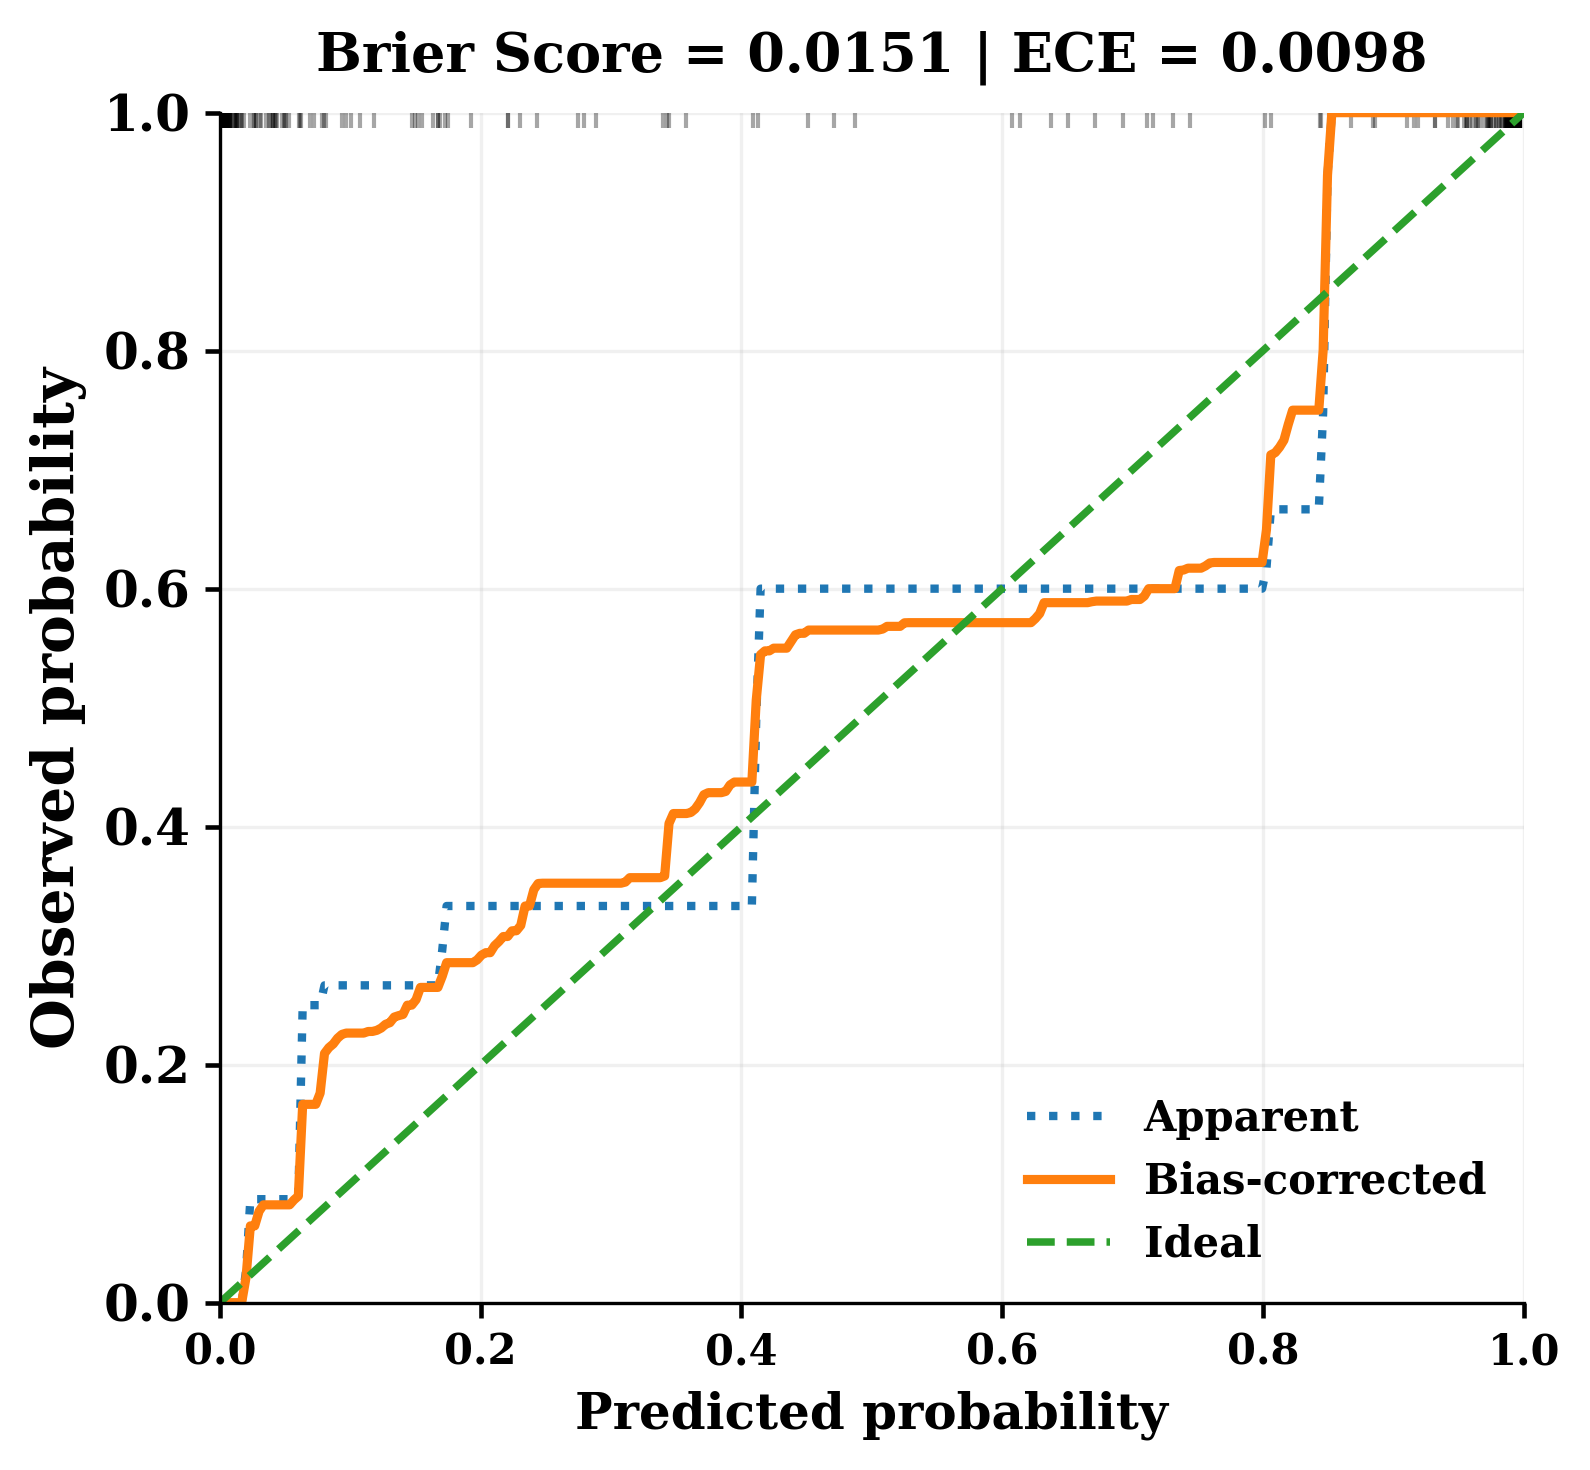

Brier Score = 0.015125
ECE = 0.009762


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

# ============================================================
# TabFGT CALIBRATION PLOT
# Apparent + Bias-corrected + Ideal
# with Brier Score and ECE
# ============================================================

MODEL_NAME = "TabFGT"

y_true = np.asarray(y_true_test_calibration, dtype=int)
y_prob = np.asarray(y_prob_test_calibration, dtype=float)

eps = 1e-8
y_prob = np.clip(y_prob, eps, 1 - eps)

rng = np.random.default_rng(42)
n_boot = 200
n_bins = 10

x_grid = np.linspace(0, 1, 300)

# apparent calibration curve
iso_app = IsotonicRegression(out_of_bounds="clip")
iso_app.fit(y_prob, y_true)
apparent_curve = iso_app.transform(x_grid)

# bootstrap bias-corrected curve
boot_curves = []
n = len(y_true)

for _ in range(n_boot):
    idx = rng.integers(0, n, n)
    y_b = y_true[idx]
    p_b = y_prob[idx]

    try:
        iso_b = IsotonicRegression(out_of_bounds="clip")
        iso_b.fit(p_b, y_b)
        curve_b = iso_b.transform(x_grid)
        boot_curves.append(curve_b)
    except Exception:
        continue

boot_curves = np.asarray(boot_curves)
bias_corrected = np.median(boot_curves, axis=0)

# ------------------------------------------------------------
# Brier score
# ------------------------------------------------------------
brier = brier_score_loss(y_true, y_prob)

# ------------------------------------------------------------
# ECE
# ------------------------------------------------------------
bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
bin_ids = np.digitize(y_prob, bin_edges[1:-1], right=True)

ece = 0.0
for b in range(n_bins):
    mask = bin_ids == b
    if np.sum(mask) == 0:
        continue

    pred_mean = np.mean(y_prob[mask])
    obs_mean = np.mean(y_true[mask])
    ece += (np.sum(mask) / len(y_true)) * abs(pred_mean - obs_mean)

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.4, 5.0), dpi=300)

# rug marks
ax.plot(y_prob, np.full_like(y_prob, 1.0), '|', color='black', markersize=7, alpha=0.35)

# lines
ax.plot(x_grid, apparent_curve, linestyle=':', linewidth=2, label='Apparent')
ax.plot(x_grid, bias_corrected, linewidth=2.2, label='Bias-corrected')
ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1.8, label='Ideal')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# bold labels
ax.set_xlabel("Predicted probability", fontsize=12, fontweight='bold')
ax.set_ylabel("Observed probability", fontsize=14, fontweight='bold')   # left side larger
ax.set_title(f"Brier Score = {brier:.4f} | ECE = {ece:.4f}", fontsize=13, fontweight='bold', pad=10)

# legend bold
legend = ax.legend(frameon=False, loc="lower right", prop={'weight': 'bold', 'size': 10})

# tick sizes
ax.tick_params(axis='x', labelsize=10, width=1.1)
ax.tick_params(axis='y', labelsize=12, width=1.1)   # left side ticks larger

# make tick text bold
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()

print(f"Brier Score = {brier:.6f}")
print(f"ECE = {ece:.6f}")

#**XAI**

XAI ANALYSIS FOR TABFGT
Explained model          : final_models[0]
Train samples available  : 4000
Test samples available   : 1000
Number of features       : 20
Classes                  : ['0', '1']

SECTION 1 — GLOBAL SHAP ANALYSIS: TOP 10 MOST IMPORTANT FEATURES


,Rank,Feature,Mean(|SHAP|)
0,1,pack_years,0.086860
1,2,crp_level,0.063781
2,3,xray_abnormal,0.055801
3,4,smoker,0.045153
4,5,fev1_x10,0.036226
5,6,oxygen_saturation,0.035869
6,7,copd,0.031774
7,8,chronic_cough,0.029231
8,9,age,0.025082
9,10,air_pollution_index,0.019345


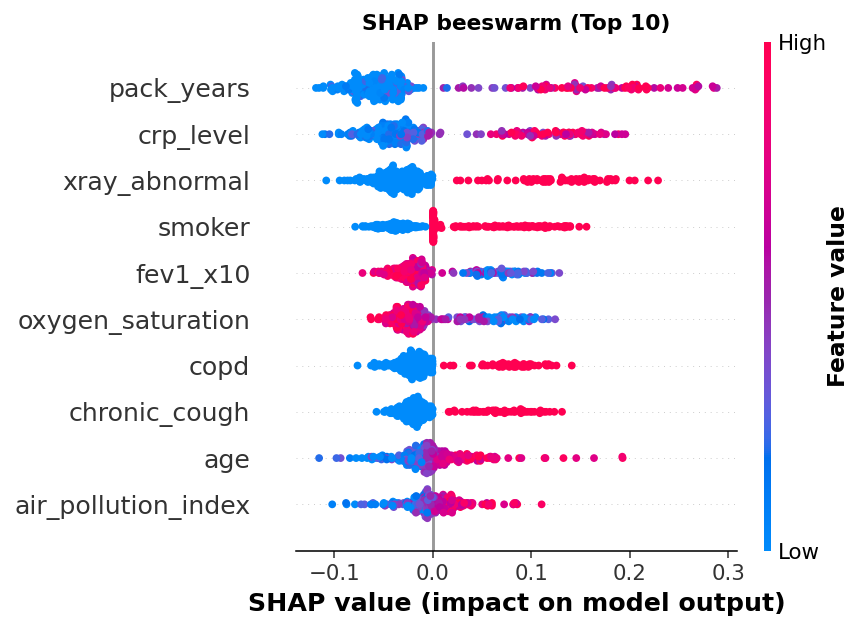

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from matplotlib.lines import Line2D
import warnings, sys, subprocess, importlib, re, textwrap
import torch
import torch.nn as nn
from IPython.display import display

warnings.filterwarnings("ignore")

# -----------------------------
# install only if missing
# -----------------------------
def _ensure_import(module_name, pip_name=None):
    try:
        return importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or module_name])
        return importlib.import_module(module_name)

shap = _ensure_import("shap")
lime_tabular_mod = _ensure_import("lime.lime_tabular", "lime")
LimeTabularExplainer = lime_tabular_mod.LimeTabularExplainer

# -----------------------------
# required variables from previous training code
# -----------------------------
required_vars = [
    "final_models", "final_preps", "X_train_df", "X_test_df", "y_test",
    "class_names", "DEVICE", "SEED"
]
missing = [v for v in required_vars if v not in globals()]
if len(missing) > 0:
    raise ValueError(f"Missing variables from previous training cell: {missing}")

if len(final_models) == 0 or len(final_preps) == 0:
    raise ValueError("final_models/final_preps are empty.")

# ------------------------------------------------------------
# choose one fitted final model
# ------------------------------------------------------------
xai_model = final_models[0]
xai_prep = final_preps[0]
xai_model.eval()

# ------------------------------------------------------------
# style: professional single-column theme
# ------------------------------------------------------------
COL_W = 6.25

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10.0,
    "axes.titlesize": 11.2,
    "axes.labelsize": 10.2,
    "xtick.labelsize": 9.4,
    "ytick.labelsize": 9.4,
    "legend.fontsize": 9.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlepad": 5,
    "font.family": "sans-serif",
})

# ── general palette ──
TEXT      = "#1F2937"
MUTED     = "#5B6472"
GRID      = "#D7DCE3"
LIGHT_GRID = "#E7EBF0"

# ── SHAP (unchanged) ──
SHAP_BLUE = "#2F6DB3"

# ── LIME  (new – lollipop style) ──
LIME_SUP     = "#2E86AB"       # steel-blue: supports explained class
LIME_OPP     = "#D64045"       # coral-red:  opposes explained class
LIME_PBAR    = "#2C3E50"       # dark navy for predicted-class bar
LIME_ALTROW  = "#F4F6F9"       # alternating-row tint
LIME_NEUTRAL = "#E0E4E8"       # neutral probability bar

# ── PDP / ICE  (new – purple-glow) ──
PDP_LINE  = "#7B2D8E"          # rich purple  (PDP mean)
PDP_BAND  = "#E8D5F0"          # soft lavender (10-90 % band)
ICE_LINE  = "#CDB0DA"          # light purple  (ICE curves)

# ── ALE  (new – teal + dual-fill) ──
ALE_LINE  = "#0E8C6B"          # deep teal
ALE_POS   = "#C8F7E1"          # mint-green fill (positive ALE)
ALE_NEG   = "#FDE2E2"          # light-coral fill (negative ALE)

# ------------------------------------------------------------
# data
# ------------------------------------------------------------
X_train_raw = X_train_df.copy().reset_index(drop=True)
X_test_raw  = X_test_df.copy().reset_index(drop=True)
y_true_test = np.asarray(y_test, dtype=int)
class_names_str = [str(c) for c in class_names]

X_train_proc = xai_prep.transform(X_train_raw)
X_test_proc  = xai_prep.transform(X_test_raw)

def resolve_processed_feature_names(prep, raw_feature_names, n_features_proc):
    names = None
    try:
        if hasattr(prep, "get_feature_names_out"):
            names = list(prep.get_feature_names_out())
    except Exception:
        names = None
    if names is not None and len(names) == n_features_proc:
        return names
    if len(raw_feature_names) == n_features_proc:
        return list(raw_feature_names)
    return [f"feature_{i}" for i in range(n_features_proc)]

feature_names_raw  = list(X_train_raw.columns)
feature_names_proc = resolve_processed_feature_names(
    xai_prep, feature_names_raw, X_train_proc.shape[1]
)

print("=" * 100)
print("XAI ANALYSIS FOR TABFGT")
print("=" * 100)
print(f"Explained model          : final_models[0]")
print(f"Train samples available  : {X_train_proc.shape[0]}")
print(f"Test samples available   : {X_test_proc.shape[0]}")
print(f"Number of features       : {X_test_proc.shape[1]}")
print(f"Classes                  : {class_names_str}")

# ============================================================
# helpers
# ============================================================

def _tensor_prob_class1_from_model_output(model_output):
    if model_output.ndim == 1:
        return torch.sigmoid(model_output)
    if model_output.ndim == 2 and model_output.shape[1] == 1:
        return torch.sigmoid(model_output[:, 0])
    if model_output.ndim == 2 and model_output.shape[1] == 2:
        probs = torch.softmax(model_output, dim=1)
        return probs[:, 1]
    raise ValueError(f"Unsupported model output shape: {tuple(model_output.shape)}")


class ShapBinaryWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        out = self.model(x)
        p1 = _tensor_prob_class1_from_model_output(out)
        p0 = 1.0 - p1
        return torch.stack([p0, p1], dim=1)


def _extract_shap_class1_values(shap_values, n_samples, n_features):
    if isinstance(shap_values, list):
        arr = np.asarray(shap_values[1] if len(shap_values) > 1 else shap_values[0])
    else:
        arr = np.asarray(shap_values)
        if arr.ndim == 3:
            if arr.shape[0] == n_samples and arr.shape[1] == n_features:
                arr = arr[:, :, 1] if arr.shape[2] > 1 else arr[:, :, 0]
            elif arr.shape[1] == n_samples and arr.shape[2] == n_features:
                arr = arr[1] if arr.shape[0] > 1 else arr[0]
            elif arr.shape[0] == n_samples and arr.shape[2] == n_features:
                arr = arr[:, 1, :] if arr.shape[1] > 1 else arr[:, 0, :]
        elif arr.ndim == 2:
            if arr.shape[0] != n_samples and arr.shape[1] == n_samples:
                arr = arr.T
    arr = np.asarray(arr)
    if arr.ndim != 2:
        raise ValueError(f"Unexpected SHAP array ndim={arr.ndim}, shape={arr.shape}")
    if arr.shape != (n_samples, n_features):
        raise ValueError(f"Unexpected SHAP shape {arr.shape}; expected ({n_samples}, {n_features})")
    return arr


@torch.no_grad()
def predict_prob_class1_processed(X_np, batch_size=1024):
    xai_model.eval()
    probs = []
    for i in range(0, len(X_np), batch_size):
        xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32, device=DEVICE)
        out = xai_model(xb)
        p1 = _tensor_prob_class1_from_model_output(out)
        probs.append(p1.detach().cpu().numpy())
    return np.concatenate(probs).astype(np.float64)


def predict_proba_processed_2col(X_np, batch_size=1024):
    p1 = predict_prob_class1_processed(X_np, batch_size=batch_size)
    p0 = 1.0 - p1
    return np.column_stack([p0, p1]).astype(np.float64)


def predict_prob_class1_raw(X_df_or_np, batch_size=1024):
    if isinstance(X_df_or_np, pd.DataFrame):
        X_raw_df = X_df_or_np.copy()
    else:
        X_raw_df = pd.DataFrame(X_df_or_np, columns=feature_names_raw)
    X_proc = xai_prep.transform(X_raw_df)
    return predict_prob_class1_processed(X_proc, batch_size=batch_size)


def predict_proba_raw_2col(X_df_or_np, batch_size=1024):
    p1 = predict_prob_class1_raw(X_df_or_np, batch_size=batch_size)
    p0 = 1.0 - p1
    return np.column_stack([p0, p1]).astype(np.float64)


def format_value(v):
    if pd.isna(v):
        return "NA"
    try:
        vf = float(v)
        if abs(vf) >= 100:   return f"{vf:.1f}"
        if abs(vf) >= 10:    return f"{vf:.2f}"
        if abs(vf) >= 1:     return f"{vf:.2f}"
        return f"{vf:.3f}"
    except Exception:
        return str(v)


def extract_base_feature_name(rule_text, feature_names):
    rule_lower = str(rule_text).lower()
    matches = [f for f in feature_names if str(f).lower() in rule_lower]
    if len(matches) == 0:
        return str(rule_text)
    return sorted(matches, key=lambda x: len(str(x)), reverse=True)[0]


def clean_rule_text(rule_text, max_width=30):
    s = str(rule_text)
    s = s.replace(" <= ", " ≤ ").replace(" >= ", " ≥ ")
    s = re.sub(r"\s+", " ", s).strip()
    if len(s) <= max_width:
        return s
    return s[:max_width - 1] + "…"


def style_axis(ax):
    ax.grid(alpha=0.18, linewidth=0.6, color=GRID)
    ax.spines["left"].set_alpha(0.25)
    ax.spines["bottom"].set_alpha(0.25)
    ax.tick_params(colors=TEXT)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)


# ============================================================
# full predictions
# ============================================================
test_prob_full = predict_prob_class1_processed(X_test_proc)
test_pred_full = (test_prob_full >= 0.5).astype(int)

# ============================================================
# sampling
# ============================================================
rng = np.random.default_rng(SEED)

background_size    = min(200, len(X_train_proc))
explain_size       = min(300, len(X_test_proc))
pdp_ice_sample_size = min(250, len(X_test_raw))
ale_reference_size = min(500, len(X_test_raw))

background_idx = rng.choice(len(X_train_proc), size=background_size, replace=False)
explain_idx    = rng.choice(len(X_test_proc),  size=explain_size,    replace=False)
pdp_ice_idx    = rng.choice(len(X_test_raw),   size=pdp_ice_sample_size, replace=False)
ale_ref_idx    = rng.choice(len(X_test_raw),   size=ale_reference_size,  replace=False)

X_background   = X_train_proc[background_idx]
X_explain      = X_test_proc[explain_idx]
X_explain_raw  = X_test_raw.iloc[explain_idx].reset_index(drop=True)
X_pdp_ice_raw  = X_test_raw.iloc[pdp_ice_idx].reset_index(drop=True)
X_ale_ref_raw  = X_test_raw.iloc[ale_ref_idx].reset_index(drop=True)

# ============================================================
# 1) SHAP: GLOBAL FEATURE IMPORTANCE (TOP 10)   *** UNCHANGED ***
# ============================================================
print("\n" + "=" * 100)
print("SECTION 1 — GLOBAL SHAP ANALYSIS: TOP 10 MOST IMPORTANT FEATURES")
print("=" * 100)

background_t = torch.tensor(X_background, dtype=torch.float32, device=DEVICE)
explain_t    = torch.tensor(X_explain,    dtype=torch.float32, device=DEVICE)

shap_model = ShapBinaryWrapper(xai_model).to(DEVICE).eval()
explainer  = shap.GradientExplainer(shap_model, background_t)
raw_shap_values = explainer.shap_values(explain_t)

shap_values = _extract_shap_class1_values(
    raw_shap_values,
    n_samples=X_explain.shape[0],
    n_features=X_explain.shape[1]
)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top10_idx     = np.argsort(mean_abs_shap)[::-1][:10]
top10_features = [feature_names_proc[i] for i in top10_idx]

shap_top10_df = pd.DataFrame({
    "Rank": np.arange(1, len(top10_idx) + 1),
    "Feature": top10_features,
    "Mean(|SHAP|)": mean_abs_shap[top10_idx]
})
display(shap_top10_df.round(6))

# SHAP beeswarm
X_explain_df_proc = pd.DataFrame(X_explain, columns=feature_names_proc)
shap.summary_plot(
    shap_values,
    X_explain_df_proc,
    feature_names=feature_names_proc,
    max_display=10,
    show=False
)
fig = plt.gcf()
fig.set_size_inches(COL_W, 4.6)
plt.title("SHAP beeswarm (Top 10)", fontsize=11.2, pad=6)
plt.tight_layout()
plt.show()

numeric_raw_features = [
    c for c in X_train_raw.columns
    if pd.api.types.is_numeric_dtype(X_train_raw[c])
]

if "pack_years" in numeric_raw_features:
    top_curve_features = ["pack_years"]
else:
    top_curve_features = [f for f in top10_features if f in numeric_raw_features][:1]

pdp_ice_outputs = {}
ale_outputs = {}


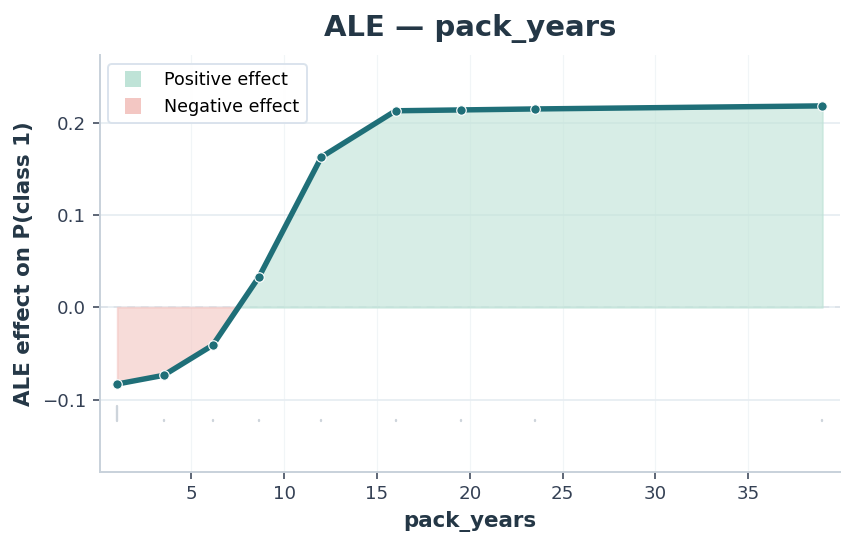

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# ALE settings / colors
# ============================================================
ale_outputs = {}

COL_W = 6.2  # change if you want wider/narrower figures

# Clean, publication-friendly palette
ALE_LINE = "#1F6F78"   # deep teal
ALE_POS  = "#BFE3D7"   # soft mint green
ALE_NEG  = "#F3C7C3"   # soft coral pink
TEXT     = "#243746"   # dark blue-gray
MUTED    = "#B8C2CC"   # soft gray
GRID     = "#E7EDF2"   # very light grid
ZERO     = "#98A2B3"   # zero reference line
SPINE    = "#C8D1DA"   # axis spine color

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": SPINE,
    "axes.labelcolor": TEXT,
    "axes.titlecolor": TEXT,
    "xtick.color": "#344054",
    "ytick.color": "#344054",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})


# ============================================================
# Helper: axis styling
# ============================================================
def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(SPINE)
    ax.spines["bottom"].set_color(SPINE)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)

    ax.grid(True, axis="y", color=GRID, linewidth=0.9)
    ax.grid(True, axis="x", color=GRID, linewidth=0.6, alpha=0.55)
    ax.set_axisbelow(True)


# ============================================================
# Compute 1D ALE
# ============================================================
def compute_1d_ale(feature_name, X_ref_df, bins=20):
    x = X_ref_df[feature_name].astype(float).values

    qs = np.quantile(x, np.linspace(0, 1, bins + 1))
    edges = np.unique(qs)

    if len(edges) < 3:
        vals = np.unique(x)
        if len(vals) < 3:
            return None
        edges = np.linspace(vals.min(), vals.max(), min(10, len(vals)))

    K = len(edges) - 1
    avg_effect = np.zeros(K, dtype=float)
    counts = np.zeros(K, dtype=float)

    for k in range(K):
        left, right = edges[k], edges[k + 1]

        if k < K - 1:
            mask = (x >= left) & (x < right)
        else:
            mask = (x >= left) & (x <= right)

        idx = np.where(mask)[0]
        counts[k] = len(idx)

        if len(idx) == 0:
            avg_effect[k] = 0.0
            continue

        X_low = X_ref_df.iloc[idx].copy()
        X_high = X_ref_df.iloc[idx].copy()
        X_low[feature_name] = left
        X_high[feature_name] = right

        avg_effect[k] = np.mean(
            predict_prob_class1_raw(X_high) - predict_prob_class1_raw(X_low)
        )

    ale = np.cumsum(avg_effect)

    # Center ALE
    if counts.sum() > 0:
        ale = ale - np.sum(ale * counts / counts.sum())

    midpoints = (edges[:-1] + edges[1:]) / 2.0

    return {
        "midpoints": midpoints,
        "ale": ale,
        "edges": edges,
        "counts": counts,
    }


# ============================================================
# Plot ALE
# ============================================================
def plot_ale_professional(feature_name, out):
    mids = out["midpoints"]
    ale = out["ale"]
    counts = out["counts"]

    fig, ax = plt.subplots(figsize=(COL_W, 4.0), facecolor="white")
    ax.set_facecolor("white")

    # Main filled areas
    ax.fill_between(
        mids, 0, ale,
        where=(ale >= 0),
        interpolate=True,
        color=ALE_POS,
        alpha=0.62,
        zorder=1,
    )
    ax.fill_between(
        mids, 0, ale,
        where=(ale < 0),
        interpolate=True,
        color=ALE_NEG,
        alpha=0.62,
        zorder=1,
    )

    # Main curve
    ax.plot(
        mids, ale,
        color=ALE_LINE,
        linewidth=2.8,
        solid_capstyle="round",
        zorder=3,
    )

    # Markers
    ax.scatter(
        mids, ale,
        s=24,
        color=ALE_LINE,
        edgecolors="white",
        linewidths=0.6,
        zorder=4,
    )

    # Zero reference line
    ax.axhline(
        0,
        linestyle=(0, (4, 3)),
        linewidth=1.0,
        color=ZERO,
        alpha=0.95,
        zorder=0,
    )

    # Margins first, then rug based on final axis limits
    ax.margins(x=0.025, y=0.16)
    y_lo, y_hi = ax.get_ylim()
    y_range = y_hi - y_lo

    # Rug / density marks
    max_c = max(np.max(counts), 1.0)
    rug_base = y_lo + 0.02 * y_range
    rug_maxh = 0.04 * y_range

    for m, c in zip(mids, counts):
        h = (c / max_c) * rug_maxh
        ax.plot(
            [m, m], [rug_base, rug_base + h],
            color=MUTED,
            alpha=0.7,
            linewidth=1.2,
            solid_capstyle="round",
            zorder=2,
        )

    # Legend
    legend_handles = [
        Line2D(
            [0], [0],
            marker="s",
            linestyle="None",
            markerfacecolor=ALE_POS,
            markeredgecolor="none",
            markersize=8,
            label="Positive effect",
        ),
        Line2D(
            [0], [0],
            marker="s",
            linestyle="None",
            markerfacecolor=ALE_NEG,
            markeredgecolor="none",
            markersize=8,
            label="Negative effect",
        ),
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper left",
        frameon=True,
        fancybox=True,
        framealpha=0.96,
        facecolor="white",
        edgecolor="#D9E2EC",
    )

    # Labels / title
    ax.set_xlabel(feature_name, fontsize=11, fontweight="semibold", color=TEXT)
    ax.set_ylabel("ALE effect on P(class 1)", fontsize=11, fontweight="semibold", color=TEXT)
    ax.set_title(f"ALE — {feature_name}", fontsize=15, fontweight="bold", pad=10, color=TEXT)

    style_axis(ax)
    plt.tight_layout()
    plt.show()


# ============================================================
# Run ALE for selected features
# ============================================================
if len(top_curve_features) == 0:
    print("No numeric raw features from SHAP top-10 were available for ALE.")
else:
    for feat_name in top_curve_features:
        out = compute_1d_ale(
            feature_name=feat_name,
            X_ref_df=X_ale_ref_raw.copy(),
            bins=20,
        )

        if out is None:
            print(f"ALE skipped for {feat_name} (not enough unique values).")
            continue

        ale_outputs[feat_name] = out
        plot_ale_professional(feat_name, out)

ale_top_df = pd.DataFrame({
    "Rank": np.arange(1, len(ale_outputs) + 1),
    "Feature": list(ale_outputs.keys()),
})

display(ale_top_df)


SECTION 2 — LIME LOCAL EXPLANATION: REPRESENTATIVE TEST CASE


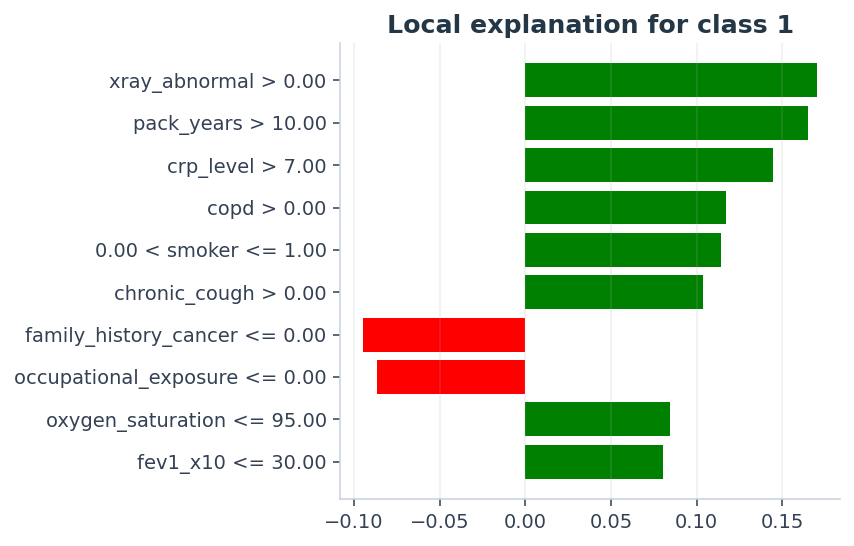

In [ ]:
# ============================================================
# 2) LIME: NORMAL LOCAL EXPLANATIONS (DROP-IN REPLACEMENT)
# ============================================================

print("\n" + "=" * 100)
print("SECTION 2 — LIME LOCAL EXPLANATION: REPRESENTATIVE TEST CASE")
print("=" * 100)

# ------------------------------------------------------------
# Use RAW space if possible so LIME rules are readable
# ------------------------------------------------------------
use_raw_lime = True
try:
    X_train_lime = X_train_raw.to_numpy(dtype=float)
    X_test_lime = X_test_raw.to_numpy(dtype=float)
    lime_feature_names = list(X_train_raw.columns)
    lime_predict_fn = predict_proba_raw_2col
except Exception:
    use_raw_lime = False
    X_train_lime = np.asarray(X_train_proc, dtype=float)
    X_test_lime = np.asarray(X_test_proc, dtype=float)
    lime_feature_names = feature_names_proc
    lime_predict_fn = predict_proba_processed_2col

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=lime_feature_names,
    class_names=[str(c) for c in class_names],
    mode="classification",
    discretize_continuous=True,
    random_state=SEED
)

# ------------------------------------------------------------
# choose one representative case
# ------------------------------------------------------------
pos_candidates = np.where(test_pred_full == 1)[0]

pos_sorted = (
    pos_candidates[np.argsort(-test_prob_full[pos_candidates])]
    if len(pos_candidates) > 0 else np.array([], dtype=int)
)

if len(pos_sorted) > 0:
    selected_lime_idx = [int(pos_sorted[0])]
else:
    selected_lime_idx = [int(np.argmax(np.abs(test_prob_full - 0.5)))]

lime_case_rows = []
lime_outputs = {}

# ------------------------------------------------------------
# standard LIME plots
# ------------------------------------------------------------
for k, idx in enumerate(selected_lime_idx, start=1):
    if use_raw_lime:
        instance = X_test_raw.iloc[idx].to_numpy(dtype=float)
    else:
        instance = X_test_proc[idx]

    pred_prob = float(test_prob_full[idx])
    pred_label = int(pred_prob >= 0.5)
    true_label = int(y_true_test[idx])

    # FIX: force both labels to be computed so no KeyError
    exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=lime_predict_fn,
        num_features=min(10, len(lime_feature_names)),
        labels=(0, 1)
    )

    available_labels = (
        exp.available_labels()
        if hasattr(exp, "available_labels")
        else list(exp.local_exp.keys())
    )

    # explain predicted class
    label_to_show = pred_label if pred_label in available_labels else available_labels[0]

    # save text explanation
    weights = exp.as_list(label=label_to_show)
    lime_outputs[idx] = weights

    lime_case_rows.append({
        "Case": k,
        "Test Index": idx,
        "True Label": true_label,
        "Predicted Label": pred_label,
        "Explained Label": label_to_show,
        "Prob(Class 1)": pred_prob
    })

    # NORMAL LIME figure
    fig = exp.as_pyplot_figure(label=label_to_show)
    fig.set_size_inches(6.2, 4.0)

    ax = plt.gca()

    ax.tick_params(axis="both", labelsize=10)
    ax.grid(axis="x", alpha=0.20)

    plt.tight_layout()
    plt.show()

lime_cases_df = pd.DataFrame(lime_case_rows)
display(lime_cases_df)


SECTION 3 — PARTIAL DEPENDENCE AND ICE PLOT: pack_years


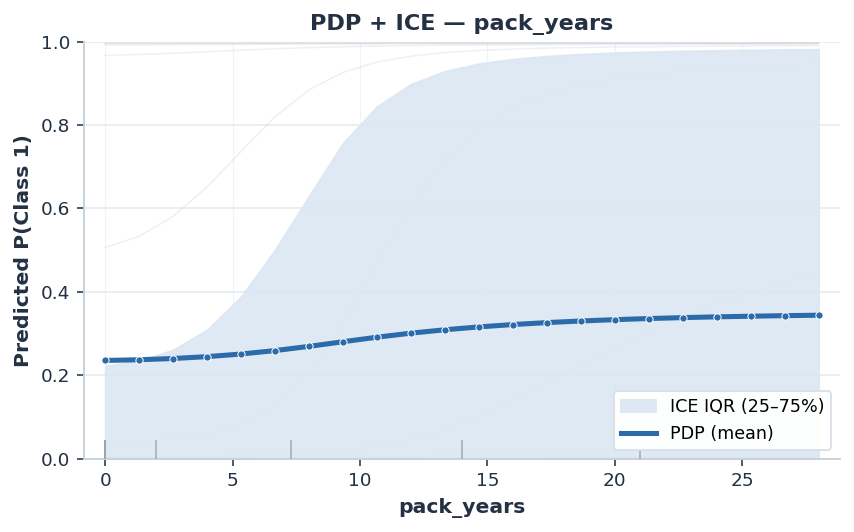

In [ ]:
# ============================================================
# 3) PDP + ICE ONLY — FIXED CLEAN VERSION
#    - uses the SAME ICE matrix for PDP and band
#    - shows IQR band (25–75%) instead of very wide 10–90%
#    - shows only a small representative subset of ICE curves
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "=" * 100)
print("SECTION 3 — PARTIAL DEPENDENCE AND ICE PLOT: pack_years")
print("=" * 100)

# ------------------------------------------------------------
# choose numeric raw features from SHAP top-10
# ------------------------------------------------------------
numeric_raw_features = [
    c for c in X_train_raw.columns
    if pd.api.types.is_numeric_dtype(X_train_raw[c])
]

top_curve_features = ["pack_years"] if "pack_years" in numeric_raw_features else [f for f in top10_features if f in numeric_raw_features][:1]
pdp_ice_outputs = {}

# ------------------------------------------------------------
# clean style
# ------------------------------------------------------------
try:
    COL_W
except NameError:
    COL_W = 6.25

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10.0,
    "axes.titlesize": 11.5,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlepad": 6,
})

PDP_COLOR   = "#2C6BAA"
ICE_COLOR   = "#C8CED8"
BAND_COLOR  = "#DCE7F3"
GRID_COLOR  = "#E7ECF2"
TEXT_COLOR  = "#233142"
SPINE_COLOR = "#C9D3DD"
RUG_COLOR   = "#9AA4B2"

def _style_axis(ax):
    ax.set_facecolor("white")
    ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.9)
    ax.grid(True, axis="x", color=GRID_COLOR, linewidth=0.6, alpha=0.55)
    ax.spines["left"].set_color(SPINE_COLOR)
    ax.spines["bottom"].set_color(SPINE_COLOR)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.tick_params(colors=TEXT_COLOR)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)
    ax.set_axisbelow(True)

# ------------------------------------------------------------
# compute PDP + ICE from same matrix
# ------------------------------------------------------------
def compute_pdp_ice_for_feature(feature_name, X_ref_df, grid_points=22):
    x_vals = X_train_raw[feature_name].astype(float).values

    lo = np.nanpercentile(x_vals, 5)
    hi = np.nanpercentile(x_vals, 95)

    if np.isclose(lo, hi):
        lo = np.nanmin(x_vals)
        hi = np.nanmax(x_vals)

    grid = np.linspace(lo, hi, grid_points)

    ice_curves = []
    for g in grid:
        X_tmp = X_ref_df.copy()
        X_tmp[feature_name] = g
        p = predict_prob_class1_raw(X_tmp)
        ice_curves.append(p)

    # shape: (n_samples, n_grid)
    ice_curves = np.asarray(ice_curves, dtype=float).T

    pdp_curve = np.mean(ice_curves, axis=0)
    q25 = np.percentile(ice_curves, 25, axis=0)
    q75 = np.percentile(ice_curves, 75, axis=0)

    return {
        "grid": grid,
        "ice_curves": ice_curves,
        "pdp_curve": pdp_curve,
        "q25": q25,
        "q75": q75,
    }

# ------------------------------------------------------------
# pick representative ICE curves (not all)
# ------------------------------------------------------------
def _select_representative_ice_indices(ice_curves, n_show=18):
    n_samples = ice_curves.shape[0]
    n_show = min(n_show, n_samples)

    # use each curve's average level as a simple summary
    curve_summary = ice_curves.mean(axis=1)
    order = np.argsort(curve_summary)

    # evenly spread across ordered curves
    idx = np.linspace(0, n_samples - 1, n_show, dtype=int)
    return order[idx]

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
def plot_pdp_ice_clean(feature_name, out, x_train_values, n_ice_show=18):
    grid = out["grid"]
    ice_curves = out["ice_curves"]
    pdp_curve = out["pdp_curve"]
    q25 = out["q25"]
    q75 = out["q75"]

    fig, ax = plt.subplots(figsize=(COL_W, 3.9), facecolor="white")

    # representative ICE curves only
    idx_show = _select_representative_ice_indices(ice_curves, n_show=n_ice_show)
    for i in idx_show:
        ax.plot(
            grid,
            ice_curves[i],
            color=ICE_COLOR,
            linewidth=0.8,
            alpha=0.30,
            zorder=1
        )

    # IQR band from the SAME ICE matrix
    ax.fill_between(
        grid,
        q25,
        q75,
        color=BAND_COLOR,
        alpha=0.90,
        zorder=2,
        label="ICE IQR (25–75%)"
    )

    # PDP mean
    ax.plot(
        grid,
        pdp_curve,
        color=PDP_COLOR,
        linewidth=2.6,
        zorder=3,
        label="PDP (mean)"
    )

    ax.scatter(
        grid,
        pdp_curve,
        s=14,
        color=PDP_COLOR,
        edgecolors="white",
        linewidths=0.5,
        zorder=4
    )

    # rug marks using training deciles
    deciles = np.percentile(x_train_values, np.arange(10, 100, 10))
    ax.vlines(
        deciles,
        0.00, 0.045,
        transform=ax.get_xaxis_transform(),
        color=RUG_COLOR,
        linewidth=1.0,
        alpha=0.70,
        zorder=5
    )

    ax.set_xlabel(feature_name)
    ax.set_ylabel("Predicted P(Class 1)")
    ax.set_title(f"PDP + ICE — {feature_name}")

    ax.set_ylim(0.0, 1.0)
    ax.margins(x=0.03)

    _style_axis(ax)

    ax.legend(
        loc="lower right",
        frameon=True,
        fancybox=True,
        framealpha=0.96,
        facecolor="white",
        edgecolor="#D9E0E8"
    )

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# generate plots
# ------------------------------------------------------------
if len(top_curve_features) == 0:
    print("No numeric raw features from SHAP top-10 were available for PDP/ICE.")
else:
    for feat_name in top_curve_features:
        out = compute_pdp_ice_for_feature(
            feature_name=feat_name,
            X_ref_df=X_pdp_ice_raw.copy(),
            grid_points=22
        )

        pdp_ice_outputs[feat_name] = out

        plot_pdp_ice_clean(
            feature_name=feat_name,
            out=out,
            x_train_values=X_train_raw[feat_name].astype(float).values,
            n_ice_show=18
        )

pdp_pack_years_df = pd.DataFrame({
    "Rank": np.arange(1, len(top_curve_features) + 1),
    "Feature": top_curve_features
})
display(pdp_pack_years_df)